We want to solve $$ \dot Y_t^m = \mu(Y_t^m,t) + \varsigma(Y_t^m,t) \dot X_t^{m,-} + \sigma(Y_t^m,t) \dot W_t^m$$ where 
- $W$ is a $d$-dimensional Brownian motion, $X$ is 1-dimensional $H$-fBm, possibly correlated with $W$; $Y$ is $n$-dimensional
- The ${}^m$ denotes piecewise-linear approximations and the ${}^-$ means lagged w.r.t. $W$ by one interval
- $\mu$ and $\varsigma$ take values in $\mathbb R^n$, $\sigma$ takes values in $\mathbb R^{n \times d}$

We begin by focusing on the case of $H = 1/2$ and $\mathrm{d}[X,W^k]_t = \rho^k \mathrm{d}t$ for some $\rho^k \in [-1,1]$. The equation then becomes $$ \mathrm{d}Y_t = \Big( \mu(Y_t,t) + \frac{\rho^k}{2}[\sigma_k,\varsigma](Y_t,t) \Big)\mathrm{d}t + \varsigma(Y_t,t) \circ \mathrm{d}X_t^- + \sigma(Y_t,t) \circ \mathrm{d}W_t $$ where $[\sigma_k,\varsigma]$ denotes the Lie bracket $\mathrm{D}\varsigma \sigma_k - \mathrm{D}\sigma_k \varsigma$. Let's take $d = 3$ and $\rho^k = \delta^{1k}$.

In [3]:
# Check whether GPU is being used (probably not necessary for most things)
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


In [2]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree

In [4]:
t0, t1 = 0,10
brownian_motion = VirtualBrownianTree(t0, t1, tol=1e-3, shape=(1,), key=jr.PRNGKey(0))

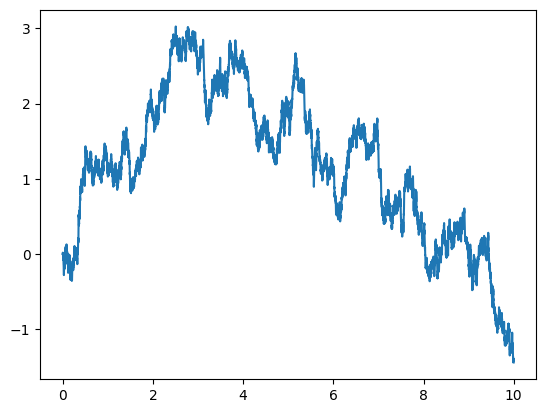

In [14]:
def bm_eval(t):
    return brownian_motion.evaluate(t)
times = jnp.arange(0, 10, 1e-3)
partition_bm_eval = jax.vmap(bm_eval)
bm_array = partition_bm_eval(times)
plt.plot(times,bm_array)

In [39]:
import random
def getkey():
    return jrandom.PRNGKey(random.randint(0, 2 ** 31 - 1))
brownian_paths = jax.vmap(VirtualBrownianTree(t0, t1, tol=1e-3, shape=(4,), key=jr.PRNGKey(0)))

In [30]:
def lagged_control(control, lag):
    return lambda s,t: control.evaluate(t - lag) - control.evaluate(s - lag)
lagged_bm = lagged_control(brownian_motion,1e-3)

<function matplotlib.pyplot.show(close=None, block=None)>

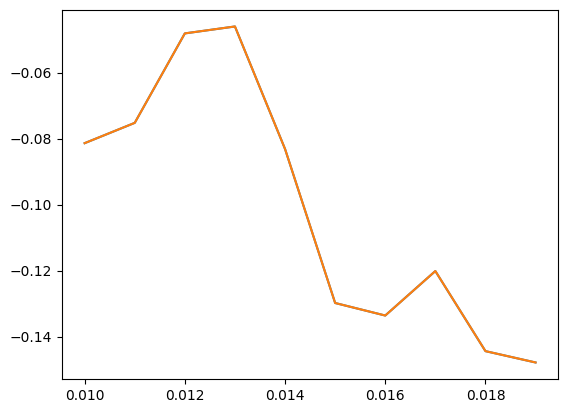

In [25]:
def lagged_bm_eval(t):
    return lagged_bm(t) - lagged_bm(0)
partition_lagged_bm_eval = jax.vmap(lagged_bm_eval)
lagged_bm_array = partition_bm_eval(times)
plt.plot(times[10:20],bm_array[10:20])
plt.plot(times[10:20],lagged_bm_array[10:20])
plt.show

In [24]:
times[10:20]

Array([0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018,
       0.019], dtype=float32)

In [28]:
lagged_bm_eval(10)

TypeError: lagged_control.<locals>.<lambda>() missing 1 required positional argument: 't'